# Prototype v6 — Sector-Only WIRE
**Config:** 100 stocks, gsector graph, M_SPECTRAL=16, OHLCV+Fundamentals (9 features), omega LR 10x

This notebook reproduces the v6 experiment and saves all outputs to Google Drive.

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import os
OUT_DIR = "/content/drive/MyDrive/3106_Projects/Projects/output/v6"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"Output directory: {OUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directory: /content/drive/MyDrive/3106_Projects/Projects/output/v6


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
from scipy.stats import spearmanr
import json, warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}, PyTorch: {torch.__version__}")

Device: cuda, PyTorch: 2.10.0+cu128


## 1. Load Data

In [ ]:
# Load CRSP daily OHLCV
crsp = pd.read_csv("<Enter your data path here>/qf0egyr4ffi0pszj.csv", parse_dates=["DlyCalDt"])
crsp = crsp.sort_values(["PERMNO", "DlyCalDt"]).reset_index(drop=True)
print(f"CRSP: {crsp.shape}, {crsp['DlyCalDt'].min()} to {crsp['DlyCalDt'].max()}")

# Load Compustat fundamentals
compustat = pd.read_csv("<Enter your data path here>/gg3axrtvut5hi5hh.csv", parse_dates=["datadate"])
compustat = compustat.rename(columns={"LPERMNO": "PERMNO"})
print(f"Compustat: {compustat.shape}, {compustat['PERMNO'].nunique()} stocks")

CRSP: (1768234, 18), 2015-01-02 00:00:00 to 2025-12-31 00:00:00
Compustat: (27236, 19), 745 stocks


## 2. Stock Filtering & Feature Engineering

In [ ]:
# Filter: 80% coverage, intersect with Compustat, top 100 by volume
date_range = crsp["DlyCalDt"].nunique()
stock_counts = crsp.groupby("PERMNO")["DlyCalDt"].count()
valid_permnos = stock_counts[stock_counts >= date_range * 0.8].index

sector_map = compustat.drop_duplicates("PERMNO", keep="last").set_index("PERMNO")["gsubind"]
gsector_map = compustat.drop_duplicates("PERMNO", keep="last").set_index("PERMNO")["gsector"]
valid_permnos = valid_permnos[valid_permnos.isin(sector_map.index)]

avg_vol = crsp[crsp["PERMNO"].isin(valid_permnos)].groupby("PERMNO")["DlyVol"].mean()
top_permnos = sorted(avg_vol.nlargest(100).index.tolist())
crsp_sub = crsp[crsp["PERMNO"].isin(top_permnos)].copy()

permno_to_idx = {p: i for i, p in enumerate(top_permnos)}
N_STOCKS = len(top_permnos)
sectors = np.array([gsector_map.get(p, -1) for p in top_permnos])
print(f"Universe: {N_STOCKS} stocks, {len(crsp_sub)} daily records")
print(f"Sector distribution:\n{pd.Series(sectors).value_counts().sort_index()}")

Universe: 100 stocks, 275177 daily records
Sector distribution:
10    15
15     2
20     8
25    14
30     9
35     9
40    14
45    15
50    10
55     3
60     1
Name: count, dtype: int64


In [ ]:
# Build OHLCV feature tensor (vectorized)
def build_feature_matrix(df, permnos, p2i):
    dates = sorted(df["DlyCalDt"].unique())
    T, N = len(dates), len(permnos)
    feat = np.full((T, N, 6), np.nan, dtype=np.float32)
    df = df.copy()
    df["_t"] = df["DlyCalDt"].map({d: t for t, d in enumerate(dates)})
    df["_n"] = df["PERMNO"].map(p2i)
    df = df.dropna(subset=["_t", "_n"])
    t, n = df["_t"].astype(int).values, df["_n"].astype(int).values
    c = df["DlyPrc"].values.astype(np.float32)
    cs = np.where(c == 0, 1.0, c)
    feat[t, n, 0] = df["DlyOpen"].values / cs
    feat[t, n, 1] = df["DlyHigh"].values / cs
    feat[t, n, 2] = df["DlyLow"].values / cs
    feat[t, n, 3] = c
    feat[t, n, 4] = np.log1p(df["DlyVol"].values)
    feat[t, n, 5] = df["DlyRet"].values
    return feat, dates

features, dates = build_feature_matrix(crsp_sub, top_permnos, permno_to_idx)
print(f"OHLCV tensor: {features.shape}")

OHLCV tensor: (2766, 100, 6)


In [ ]:
# Add Compustat fundamental features (ROE, leverage, profit margin, log assets)
FUND_FEATURES = ["roe", "leverage", "profit_margin", "log_assets"]
fund = compustat[["PERMNO", "datadate", "rdq", "atq", "ceqq", "niq"]].copy()
fund["datadate"] = pd.to_datetime(fund["datadate"])
fund["rdq"] = pd.to_datetime(fund["rdq"])
fund["avail_date"] = fund["rdq"].fillna(fund["datadate"] + pd.Timedelta(days=45))

def safe_ratio(num, denom, clip=10):
    return (num / denom.replace(0, np.nan)).clip(-clip, clip)

fund["roe"] = safe_ratio(fund["niq"], fund["ceqq"])
fund["leverage"] = safe_ratio(fund["atq"], fund["ceqq"])
fund["profit_margin"] = safe_ratio(fund["niq"], fund["atq"])
fund["log_assets"] = np.log1p(fund["atq"].clip(lower=0))

def merge_fundamentals(feat, dates, permnos, p2i, fund_df):
    T, N, F_old = feat.shape
    F_new = len(FUND_FEATURES)
    ff = np.full((T, N, F_new), np.nan, dtype=np.float32)
    for p in permnos:
        ni = p2i[p]
        sf = fund_df[fund_df["PERMNO"] == p].sort_values("avail_date")
        for _, r in sf.iterrows():
            for t, d in enumerate(dates):
                if d >= r["avail_date"]:
                    ff[t, ni, :] = [r[c] for c in FUND_FEATURES]
    for n in range(N):
        for f in range(F_new):
            lv = np.nan
            for t in range(T):
                if not np.isnan(ff[t, n, f]): lv = ff[t, n, f]
                else: ff[t, n, f] = lv
    return np.concatenate([feat, ff], axis=2)

features = merge_fundamentals(features, dates, top_permnos, permno_to_idx, fund)
print(f"Full features: {features.shape}  [O/C, H/C, L/C, Close, logVol, Ret, ROE, Lev, PM, LogA]")

Full features: (2766, 100, 10)  [O/C, H/C, L/C, Close, logVol, Ret, ROE, Lev, PM, LogA]


## 3. Sector Graph & Spectral Coordinates

Sector: 541 edges, density=0.1093
Sub-industry: 99 edges


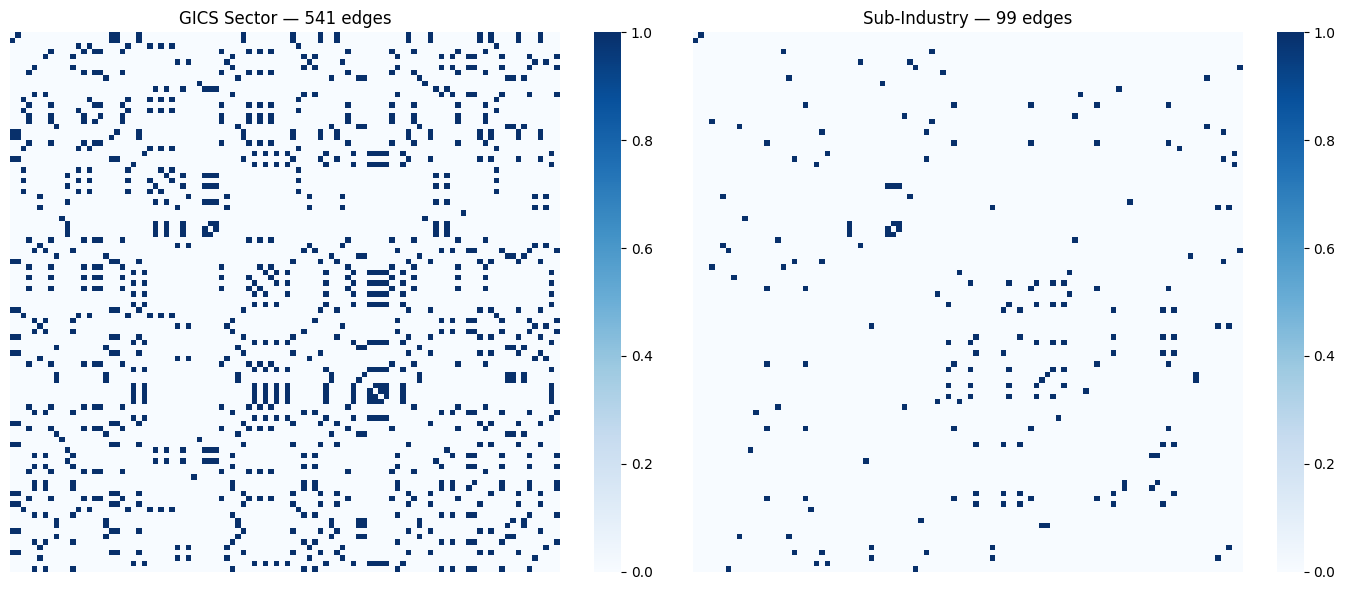

In [ ]:
# Sector graph construction
def build_adjacency(labels):
    L = labels.reshape(-1, 1)
    A = ((L == L.T) & (L != -1)).astype(np.float32)
    np.fill_diagonal(A, 0)
    return A

A_sector = build_adjacency(sectors)
sub_industries = np.array([sector_map.get(p, -1) for p in top_permnos])
A_subind = build_adjacency(sub_industries)
A_graph = A_sector

n_sec = int(A_sector.sum() / 2)
n_sub = int(A_subind.sum() / 2)
print(f"Sector: {n_sec} edges, density={n_sec/(N_STOCKS*(N_STOCKS-1)/2):.4f}")
print(f"Sub-industry: {n_sub} edges")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(A_sector, cmap="Blues", xticklabels=False, yticklabels=False, ax=axes[0])
axes[0].set_title(f"GICS Sector — {n_sec} edges")
sns.heatmap(A_subind, cmap="Blues", xticklabels=False, yticklabels=False, ax=axes[1])
axes[1].set_title(f"Sub-Industry — {n_sub} edges")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/adjacency_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

Spectral coords: (100, 16), gap=-0.0000


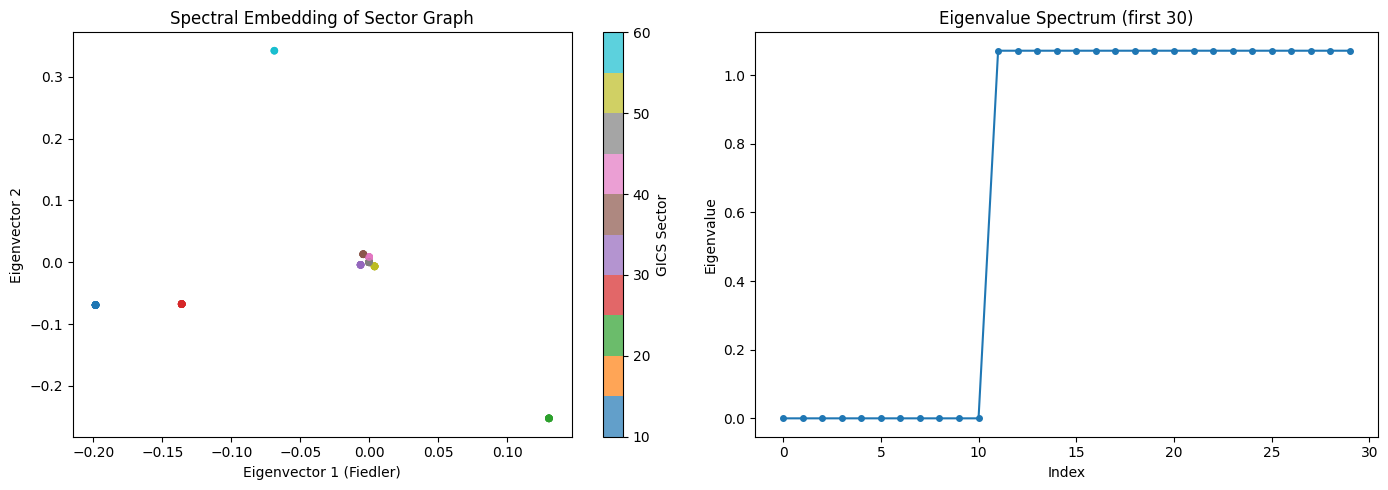

In [ ]:
# Laplacian eigendecomposition — v6: sector-only, M=16
M_SPECTRAL = 16
L_graph = laplacian(A_graph, normed=True)
eigenvalues, eigenvectors = eigh(L_graph)
spectral_coords = eigenvectors[:, 1:M_SPECTRAL + 1].astype(np.float32)
print(f"Spectral coords: {spectral_coords.shape}, gap={eigenvalues[1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(spectral_coords[:, 0], spectral_coords[:, 1],
                     c=sectors, cmap="tab10", alpha=0.7, s=20)
axes[0].set_xlabel("Eigenvector 1 (Fiedler)"); axes[0].set_ylabel("Eigenvector 2")
axes[0].set_title("Spectral Embedding of Sector Graph")
plt.colorbar(sc, ax=axes[0], label="GICS Sector")
axes[1].plot(eigenvalues[:30], "o-", markersize=4)
axes[1].set_xlabel("Index"); axes[1].set_ylabel("Eigenvalue")
axes[1].set_title("Eigenvalue Spectrum (first 30)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/spectral_embedding.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Dataset

In [ ]:
LOOKBACK = 20; HORIZON = 5; INPUT_DIM = 9

class StockDataset(Dataset):
    def __init__(self, features, lookback=LOOKBACK, horizon=HORIZON):
        self.samples = []
        T, N, F = features.shape
        idx = [0, 1, 2, 4, 5, 6, 7, 8, 9]  # skip raw close at 3
        for t in range(lookback, T - horizon):
            x = features[t-lookback:t, :, :][:, :, idx]
            y = (features[t+horizon, :, 3] / features[t, :, 3]) - 1.0
            valid = ~(np.isnan(x).any(axis=(0,2)) | np.isnan(y))
            if valid.sum() < N * 0.5: continue
            self.samples.append((np.nan_to_num(x).transpose(1,0,2), np.nan_to_num(y)))
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        x, y = self.samples[i]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

dataset = StockDataset(features)
n_total = len(dataset)
n_train, n_val = int(0.7*n_total), int(0.15*n_total)
n_test = n_total - n_train - n_val
train_ds = torch.utils.data.Subset(dataset, range(n_train))
val_ds = torch.utils.data.Subset(dataset, range(n_train, n_train+n_val))
test_ds = torch.utils.data.Subset(dataset, range(n_train+n_val, n_total))
print(f"Samples: train={n_train}, val={n_val}, test={n_test}")
print(f"Shape: X={dataset[0][0].shape}, Y={dataset[0][1].shape}")

Samples: train=1819, val=390, test=391
Shape: X=torch.Size([100, 20, 9]), Y=torch.Size([100])


## 5. Models

In [ ]:
# Baseline LSTM
class BaselineLSTM(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=dropout)
        self.head = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1))
    def forward(self, x):
        B, N, T, F = x.shape
        _, (h, _) = self.lstm(x.reshape(B*N, T, F))
        pred = self.head(h[-1]).squeeze(-1)
        return pred.reshape(B, N), h[-1].reshape(B, N, -1)

# WIRE
class WIRE(nn.Module):
    def __init__(self, d_model, m_spectral):
        super().__init__()
        self.omega = nn.Parameter(torch.randn(d_model//2, m_spectral) * 1.0)
    def forward(self, z, sc):
        B, N, H, d = z.shape
        nb = d // 2
        theta = sc @ self.omega.T
        z = z.reshape(B, N, H, nb, 2)
        cos_t = torch.cos(theta)[None,:,None,:,None]
        sin_t = torch.sin(theta)[None,:,None,:,None]
        z0, z1 = z[...,0:1], z[...,1:2]
        return torch.cat([z0*cos_t - z1*sin_t, z0*sin_t + z1*cos_t], dim=-1).reshape(B,N,H,d)

# Graph Transformer with WIRE + gated residual
class WIREAttentionLayer(nn.Module):
    def __init__(self, d_model=64, n_heads=4, m_spectral=16, dropout=0.2):
        super().__init__()
        self.d_model, self.n_heads, self.d_k = d_model, n_heads, d_model//n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.wire = WIRE(self.d_k, m_spectral)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)
        self.gate = nn.Parameter(torch.tensor(0.0))
    def forward(self, x, sc):
        B, N, _ = x.shape; H, dk = self.n_heads, self.d_k
        Q = self.wire(self.W_q(x).reshape(B,N,H,dk), sc)
        K = self.wire(self.W_k(x).reshape(B,N,H,dk), sc)
        V = self.W_v(x).reshape(B,N,H,dk)
        Q, K, V = Q.permute(0,2,1,3), K.permute(0,2,1,3), V.permute(0,2,1,3)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2,-1)) / dk**0.5, dim=-1)
        attn = self.dropout(attn)
        out = self.W_o(torch.matmul(attn, V).permute(0,2,1,3).reshape(B,N,self.d_model))
        return self.norm(x + torch.sigmoid(self.gate) * out), attn

class GraphTransformerWIRE(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=64, n_heads=4, n_layers=2, m_spectral=16, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=dropout)
        self.attn_layers = nn.ModuleList([WIREAttentionLayer(hidden_dim, n_heads, m_spectral, dropout) for _ in range(n_layers)])
        self.ffns = nn.ModuleList([nn.Sequential(nn.Linear(hidden_dim, hidden_dim*2), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim*2, hidden_dim), nn.LayerNorm(hidden_dim)) for _ in range(n_layers)])
        self.head = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1))
    def forward(self, x, sc):
        B, N, T, F = x.shape
        _, (h, _) = self.lstm(x.reshape(B*N, T, F))
        embed = h[-1].reshape(B, N, self.hidden_dim)
        attn_maps = []
        for al, ff in zip(self.attn_layers, self.ffns):
            embed, attn = al(embed, sc); embed = ff(embed) + embed; attn_maps.append(attn)
        return self.head(embed).squeeze(-1), attn_maps

print(f"BaselineLSTM: {sum(p.numel() for p in BaselineLSTM().parameters()):,} params")
print(f"GraphTransformerWIRE: {sum(p.numel() for p in GraphTransformerWIRE(m_spectral=M_SPECTRAL).parameters()):,} params")

BaselineLSTM: 54,593 params
GraphTransformerWIRE: 121,795 params


## 6. Training

In [ ]:
# Training utilities
def rank_ic(pred, actual):
    p, a = pred.detach().cpu().numpy().flatten(), actual.detach().cpu().numpy().flatten()
    m = ~(np.isnan(p) | np.isnan(a))
    if m.sum() < 10: return 0.0
    c, _ = spearmanr(p[m], a[m])
    return c if not np.isnan(c) else 0.0

def train_epoch(model, loader, opt, sc=None, mt="lstm"):
    model.train(); tl, ti, n = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device); opt.zero_grad()
        pred = model(x)[0] if mt=="lstm" else model(x, sc)[0]
        loss = F.mse_loss(pred, y); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        tl += loss.item(); ti += rank_ic(pred, y); n += 1
    return tl/n, ti/n

@torch.no_grad()
def evaluate(model, loader, sc=None, mt="lstm"):
    model.eval(); tl, ti, n = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)[0] if mt=="lstm" else model(x, sc)[0]
        tl += F.mse_loss(pred, y).item(); ti += rank_ic(pred, y); n += 1
    return tl/n, ti/n

def train_model(model, opt, ltr, lva, sc=None, mt="lstm", epochs=150, patience=30, warmup=5):
    best_ic, best_st, wait = -np.inf, None, 0
    hist = {"train_loss":[], "val_loss":[], "train_ic":[], "val_ic":[]}
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=10, min_lr=1e-6)
    blrs = [pg["lr"] for pg in opt.param_groups]
    for ep in range(epochs):
        if ep < warmup:
            for pg, bl in zip(opt.param_groups, blrs): pg["lr"] = bl*(ep+1)/warmup
        tl, ti = train_epoch(model, ltr, opt, sc, mt)
        vl, vi = evaluate(model, lva, sc, mt)
        if ep >= warmup: sched.step(vl)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_ic"].append(ti); hist["val_ic"].append(vi)
        if vi > best_ic: best_ic = vi; best_st = {k:v.cpu().clone() for k,v in model.state_dict().items()}; wait=0
        else: wait += 1
        if (ep+1) % 10 == 0:
            print(f"  Epoch {ep+1:3d} | TrLoss:{tl:.6f} TrIC:{ti:+.4f} | VaLoss:{vl:.6f} VaIC:{vi:+.4f} | best:{best_ic:+.4f} lr:{opt.param_groups[0]['lr']:.1e}")
        if wait >= patience: print(f"  Early stop at epoch {ep+1} (best val IC: {best_ic:+.4f})"); break
    if best_st: model.load_state_dict(best_st)
    print(f"  Done {len(hist['train_loss'])} epochs, best val IC: {best_ic:+.4f}")
    return hist

In [ ]:
# 5-seed robustness loop
BATCH_SIZE = 16; LR = 1e-3; N_SEEDS = 5
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
sc_tensor = torch.tensor(spectral_coords, dtype=torch.float32).to(device)

all_results = []  # collect per-seed results
all_histories = {"lstm": [], "wire": []}
best_wire_model_state = None
best_wire_ic = -np.inf

for seed in range(N_SEEDS):
    print(f"\n{'#'*70}")
    print(f"# SEED {seed+1}/{N_SEEDS}")
    print(f"{'#'*70}")

    torch.manual_seed(seed * 42)
    np.random.seed(seed * 42)

    # --- Baseline LSTM ---
    model_lstm = BaselineLSTM().to(device)
    opt_lstm = torch.optim.AdamW(model_lstm.parameters(), lr=LR, weight_decay=1e-4)
    h_lstm = train_model(model_lstm, opt_lstm, train_loader, val_loader, mt="lstm")

    # --- WIRE ---
    model_wire = GraphTransformerWIRE(m_spectral=M_SPECTRAL).to(device)
    wp, gp, op = [], [], []
    for name, p in model_wire.named_parameters():
        if "omega" in name: wp.append(p)
        elif "gate" in name: gp.append(p)
        else: op.append(p)
    opt_wire = torch.optim.AdamW([
        {"params": op, "lr": LR, "weight_decay": 1e-4},
        {"params": wp, "lr": LR*10, "weight_decay": 0.0},
        {"params": gp, "lr": LR*5, "weight_decay": 0.0},
    ])
    h_wire = train_model(model_wire, opt_wire, train_loader, val_loader, sc_tensor, mt="wire")

    # Evaluate
    tl_lstm, ti_lstm = evaluate(model_lstm, test_loader, mt="lstm")
    tl_wire, ti_wire = evaluate(model_wire, test_loader, sc_tensor, mt="wire")

    # Attention ratio
    model_wire.eval()
    with torch.no_grad():
        sx, _ = test_ds[0]
        _, amaps = model_wire(sx.unsqueeze(0).to(device), sc_tensor)
    a = amaps[-1][0, 0].cpu().numpy()
    same = a[A_graph > 0].mean()
    diff = a[(A_graph == 0) & ~np.eye(N_STOCKS, dtype=bool)].mean()
    ar = same / diff if diff > 0 else float('inf')

    # Gate values
    gates = {}
    for name, p in model_wire.named_parameters():
        if "gate" in name:
            gates[name] = torch.sigmoid(p).item()

    result = {
        "seed": seed, "lstm_mse": tl_lstm, "lstm_ic": ti_lstm,
        "wire_mse": tl_wire, "wire_ic": ti_wire,
        "attn_ratio": ar, "gates": gates,
    }
    all_results.append(result)
    all_histories["lstm"].append(h_lstm)
    all_histories["wire"].append(h_wire)

    # Track best WIRE model for attention visualization
    if ti_wire > best_wire_ic:
        best_wire_ic = ti_wire
        best_wire_model_state = {k: v.cpu().clone() for k, v in model_wire.state_dict().items()}
        best_lstm_model_state = {k: v.cpu().clone() for k, v in model_lstm.state_dict().items()}
        best_seed = seed

    print(f"  → LSTM IC: {ti_lstm:+.4f} | WIRE IC: {ti_wire:+.4f} | Attn ratio: {ar:.2f}x")

# Reload best models for visualization
model_wire = GraphTransformerWIRE(m_spectral=M_SPECTRAL).to(device)
model_wire.load_state_dict(best_wire_model_state)
model_lstm = BaselineLSTM().to(device)
model_lstm.load_state_dict(best_lstm_model_state)
print(f"\nBest seed: {best_seed} (WIRE IC: {best_wire_ic:+.4f})")


######################################################################
# SEED 1/5
######################################################################
  Epoch  10 | TrLoss:0.005786 TrIC:+0.0056 | VaLoss:0.002919 VaIC:-0.0141 | best:-0.0118 lr:1.0e-03
  Epoch  20 | TrLoss:0.005665 TrIC:+0.0082 | VaLoss:0.002827 VaIC:-0.0148 | best:-0.0116 lr:5.0e-04
  Epoch  30 | TrLoss:0.005654 TrIC:+0.0100 | VaLoss:0.002829 VaIC:-0.0136 | best:-0.0091 lr:5.0e-04
  Epoch  40 | TrLoss:0.005646 TrIC:+0.0120 | VaLoss:0.002824 VaIC:-0.0212 | best:-0.0051 lr:5.0e-04
  Epoch  50 | TrLoss:0.005642 TrIC:+0.0080 | VaLoss:0.002821 VaIC:-0.0130 | best:-0.0051 lr:5.0e-04
  Epoch  60 | TrLoss:0.005636 TrIC:+0.0133 | VaLoss:0.002833 VaIC:-0.0100 | best:-0.0051 lr:2.5e-04
  Early stop at epoch 62 (best val IC: -0.0051)
  Done 62 epochs, best val IC: -0.0051
  Epoch  10 | TrLoss:0.005679 TrIC:+0.0005 | VaLoss:0.002913 VaIC:-0.0085 | best:+0.0090 lr:1.0e-03
  Epoch  20 | TrLoss:0.005652 TrIC:+0.0066 | VaLoss:0.00282

## 7. Results & Visualization

In [ ]:
# Multi-seed test results summary
lstm_ics = [r["lstm_ic"] for r in all_results]
wire_ics = [r["wire_ic"] for r in all_results]
lstm_mses = [r["lstm_mse"] for r in all_results]
wire_mses = [r["wire_mse"] for r in all_results]
attn_ratios = [r["attn_ratio"] for r in all_results]

print(f"{'='*60}")
print(f"TEST RESULTS — {N_SEEDS} Seeds")
print(f"{'='*60}")
print(f"\nPer-seed results:")
print(f"{'Seed':<6} {'LSTM IC':>10} {'WIRE IC':>10} {'Attn Ratio':>12}")
print(f"{'-'*40}")
for r in all_results:
    print(f"{r['seed']:<6} {r['lstm_ic']:>+10.4f} {r['wire_ic']:>+10.4f} {r['attn_ratio']:>12.2f}x")

print(f"\n{'='*60}")
print(f"AGGREGATE (mean ± std)")
print(f"{'='*60}")
print(f"{'Metric':<20} {'LSTM':>18} {'WIRE':>18}")
print(f"{'-'*58}")
print(f"{'Rank IC':<20} {np.mean(lstm_ics):>+.4f} ± {np.std(lstm_ics):.4f}   {np.mean(wire_ics):>+.4f} ± {np.std(wire_ics):.4f}")
print(f"{'MSE Loss':<20} {np.mean(lstm_mses):>.6f} ± {np.std(lstm_mses):.6f}   {np.mean(wire_mses):>.6f} ± {np.std(wire_mses):.6f}")
print(f"{'Attn Ratio':<20} {'—':>18} {np.mean(attn_ratios):>.2f}x ± {np.std(attn_ratios):.2f}")

# WIRE wins how often?
wire_wins = sum(1 for l, w in zip(lstm_ics, wire_ics) if w > l)
print(f"\nWIRE > LSTM in {wire_wins}/{N_SEEDS} seeds ({wire_wins/N_SEEDS*100:.0f}%)")

# Is the mean IC difference significant? (paired t-test)
from scipy.stats import ttest_rel
if N_SEEDS >= 3:
    t_stat, p_val = ttest_rel(wire_ics, lstm_ics)
    print(f"Paired t-test (WIRE - LSTM): t={t_stat:.3f}, p={p_val:.3f}")
    if p_val < 0.05:
        print("  → Statistically significant at α=0.05")
    else:
        print(f"  → NOT significant (p={p_val:.3f} > 0.05) — expected with N={N_STOCKS} stocks")

TEST RESULTS — 5 Seeds

Per-seed results:
Seed      LSTM IC    WIRE IC   Attn Ratio
----------------------------------------
0         +0.0152    +0.0259         0.98x
1         +0.0096    -0.0189         0.88x
2         -0.0053    +0.0176         1.06x
3         +0.0064    -0.0153         1.03x
4         -0.0260    +0.0064         0.88x

AGGREGATE (mean ± std)
Metric                             LSTM               WIRE
----------------------------------------------------------
Rank IC              -0.0000 ± 0.0146   +0.0031 ± 0.0177
MSE Loss             0.003372 ± 0.000043   0.003409 ± 0.000056
Attn Ratio                            — 0.97x ± 0.08

WIRE > LSTM in 3/5 seeds (60%)
Paired t-test (WIRE - LSTM): t=0.263, p=0.806
  → NOT significant (p=0.806 > 0.05) — expected with N=100 stocks


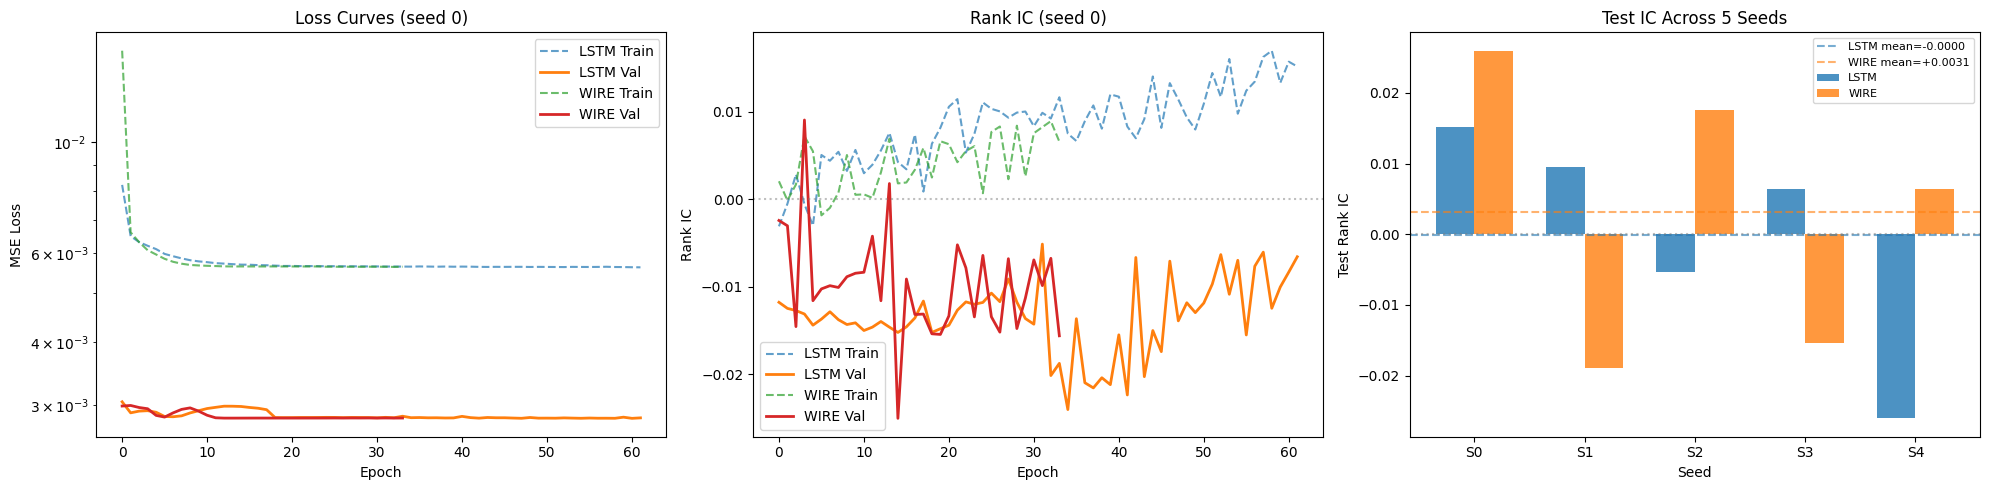

In [ ]:
# Training curves (best seed) + IC distribution across seeds
best_h_lstm = all_histories["lstm"][best_seed]
best_h_wire = all_histories["wire"][best_seed]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Loss curves (best seed)
axes[0].plot(best_h_lstm["train_loss"], label="LSTM Train", ls="--", alpha=0.7)
axes[0].plot(best_h_lstm["val_loss"], label="LSTM Val", lw=2)
axes[0].plot(best_h_wire["train_loss"], label="WIRE Train", ls="--", alpha=0.7)
axes[0].plot(best_h_wire["val_loss"], label="WIRE Val", lw=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title(f"Loss Curves (seed {best_seed})"); axes[0].legend(); axes[0].set_yscale("log")

# IC curves (best seed)
axes[1].plot(best_h_lstm["train_ic"], label="LSTM Train", ls="--", alpha=0.7)
axes[1].plot(best_h_lstm["val_ic"], label="LSTM Val", lw=2)
axes[1].plot(best_h_wire["train_ic"], label="WIRE Train", ls="--", alpha=0.7)
axes[1].plot(best_h_wire["val_ic"], label="WIRE Val", lw=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Rank IC")
axes[1].set_title(f"Rank IC (seed {best_seed})"); axes[1].legend()
axes[1].axhline(0, color="gray", ls=":", alpha=0.5)

# IC distribution across all seeds
x = np.arange(N_SEEDS)
w = 0.35
axes[2].bar(x - w/2, lstm_ics, w, label="LSTM", color="#1f77b4", alpha=0.8)
axes[2].bar(x + w/2, wire_ics, w, label="WIRE", color="#ff7f0e", alpha=0.8)
axes[2].axhline(np.mean(lstm_ics), color="#1f77b4", ls="--", alpha=0.6, label=f"LSTM mean={np.mean(lstm_ics):+.4f}")
axes[2].axhline(np.mean(wire_ics), color="#ff7f0e", ls="--", alpha=0.6, label=f"WIRE mean={np.mean(wire_ics):+.4f}")
axes[2].axhline(0, color="gray", ls=":", alpha=0.5)
axes[2].set_xlabel("Seed"); axes[2].set_ylabel("Test Rank IC")
axes[2].set_title(f"Test IC Across {N_SEEDS} Seeds"); axes[2].legend(fontsize=8)
axes[2].set_xticks(x); axes[2].set_xticklabels([f"S{i}" for i in range(N_SEEDS)])

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

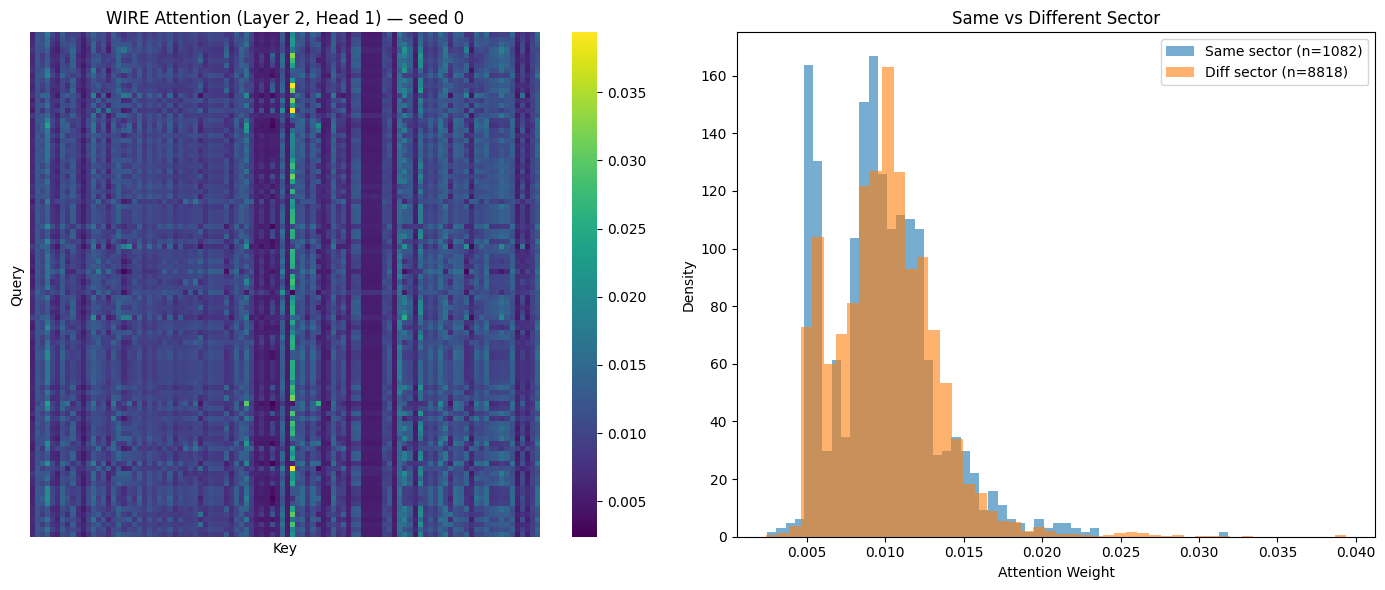

Best seed attention — same: 0.009812, diff: 0.010027, ratio: 0.98x
Mean attention ratio across all seeds: 0.97x ± 0.08


In [ ]:
# Attention analysis (best seed model)
model_wire.eval()
with torch.no_grad():
    sx, _ = test_ds[0]
    _, attn_maps = model_wire(sx.unsqueeze(0).to(device), sc_tensor)

attn = attn_maps[-1][0, 0].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(attn, cmap="viridis", xticklabels=False, yticklabels=False, ax=axes[0])
axes[0].set_title(f"WIRE Attention (Layer 2, Head 1) — seed {best_seed}")
axes[0].set_xlabel("Key"); axes[0].set_ylabel("Query")

same = attn[A_graph > 0].flatten()
diff = attn[(A_graph == 0) & ~np.eye(N_STOCKS, dtype=bool)].flatten()
axes[1].hist(same, bins=50, alpha=0.6, label=f"Same sector (n={len(same)})", density=True)
axes[1].hist(diff, bins=50, alpha=0.6, label=f"Diff sector (n={len(diff)})", density=True)
axes[1].set_xlabel("Attention Weight"); axes[1].set_ylabel("Density")
axes[1].set_title("Same vs Different Sector"); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/attention_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

ratio = same.mean() / diff.mean()
print(f"Best seed attention — same: {same.mean():.6f}, diff: {diff.mean():.6f}, ratio: {ratio:.2f}x")
print(f"Mean attention ratio across all seeds: {np.mean(attn_ratios):.2f}x ± {np.std(attn_ratios):.2f}")

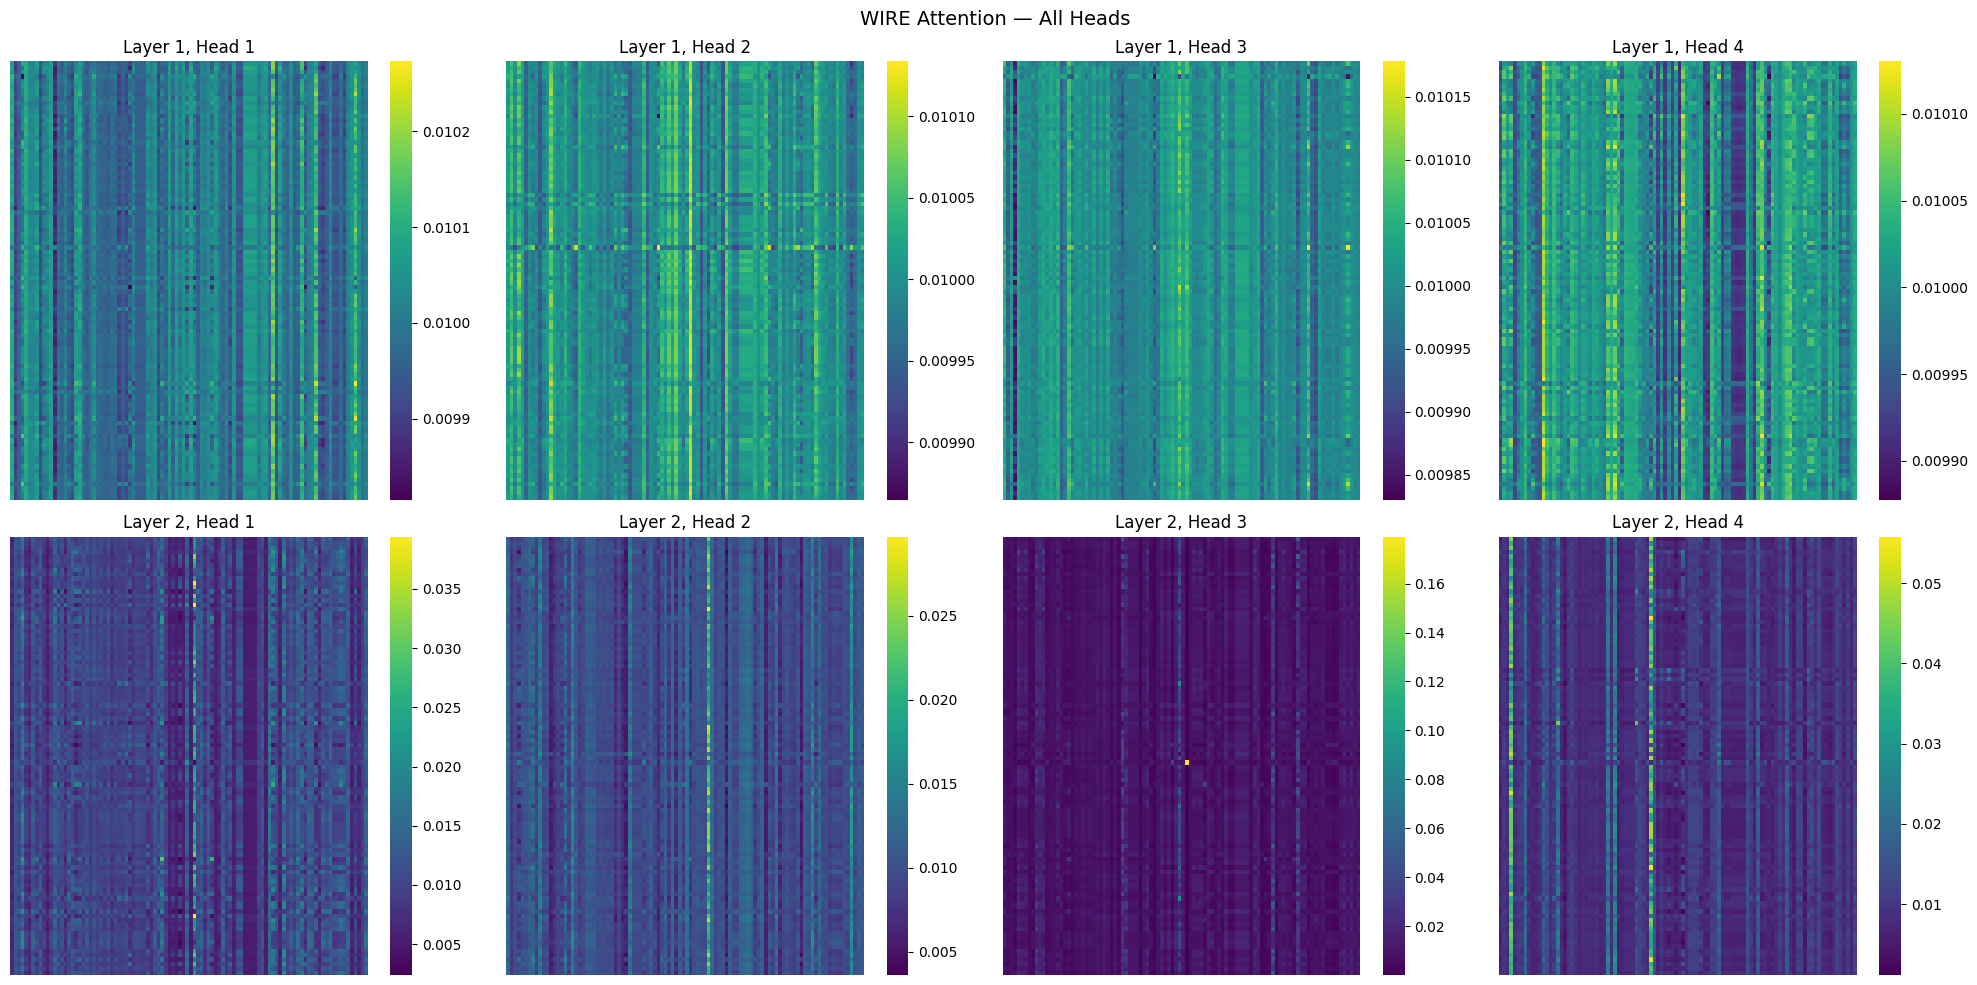

In [ ]:
# All heads attention maps
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for li in range(2):
    al = attn_maps[li][0].cpu().numpy()
    for hi in range(4):
        sns.heatmap(al[hi], cmap="viridis", xticklabels=False, yticklabels=False, ax=axes[li, hi])
        axes[li, hi].set_title(f"Layer {li+1}, Head {hi+1}")
plt.suptitle("WIRE Attention — All Heads", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/attention_all_heads.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Save all metrics to JSON
results = {
    "version": "v6",
    "n_seeds": N_SEEDS,
    "config": {"N_STOCKS": N_STOCKS, "M_SPECTRAL": M_SPECTRAL, "INPUT_DIM": INPUT_DIM,
               "graph": "gsector", "dropout": 0.2, "omega_lr": "10x", "gate_lr": "5x"},
    "aggregate": {
        "lstm_ic_mean": float(np.mean(lstm_ics)), "lstm_ic_std": float(np.std(lstm_ics)),
        "wire_ic_mean": float(np.mean(wire_ics)), "wire_ic_std": float(np.std(wire_ics)),
        "lstm_mse_mean": float(np.mean(lstm_mses)), "wire_mse_mean": float(np.mean(wire_mses)),
        "attn_ratio_mean": float(np.mean(attn_ratios)), "attn_ratio_std": float(np.std(attn_ratios)),
        "wire_wins": wire_wins,
    },
    "per_seed": all_results,
    "best_seed": best_seed,
    "graph": {"sector_edges": int(A_sector.sum()/2),
              "density": float(A_sector.sum()/2 / (N_STOCKS*(N_STOCKS-1)/2)),
              "eigenvalue_gap": float(eigenvalues[1])},
    "dataset": {"train": n_train, "val": n_val, "test": n_test},
    "params": {"lstm": sum(p.numel() for p in BaselineLSTM().parameters()),
               "wire": sum(p.numel() for p in GraphTransformerWIRE(m_spectral=M_SPECTRAL).parameters())},
}

with open(f"{OUT_DIR}/metrics.json", "w") as f:
    json.dump(results, f, indent=2, default=str)

# Save best seed training history
with open(f"{OUT_DIR}/training_history.json", "w") as f:
    json.dump({"lstm": all_histories["lstm"][best_seed],
               "wire": all_histories["wire"][best_seed]}, f, indent=2)

print(f"All outputs saved to {OUT_DIR}/")
print(f"Files: adjacency_matrices.png, spectral_embedding.png, training_curves.png,")
print(f"       attention_analysis.png, attention_all_heads.png, metrics.json, training_history.json")

All outputs saved to /content/drive/MyDrive/3106_Projects/Projects/output/v6/
Files: adjacency_matrices.png, spectral_embedding.png, training_curves.png,
       attention_analysis.png, attention_all_heads.png, metrics.json, training_history.json
